In [1]:
import pandas as pd
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


df=pd.read_csv(r"C:\Users\shrut\Downloads\archive (4).zip")

In [2]:
df.head(10)

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
5,haircare,SKU5,1.699976,87,147,2828.348746,Non-binary,90,27,66,...,Bangalore,10,104,17,56.766476,Fail,2.779194,Road,Route A,235.461237
6,skincare,SKU6,4.078333,48,65,7823.476560,Male,11,15,58,...,Kolkata,14,314,24,1.085069,Pending,1.000911,Sea,Route A,134.369097
7,cosmetics,SKU7,42.958384,59,426,8496.103813,Female,93,17,11,...,Bangalore,22,564,1,99.466109,Fail,0.398177,Road,Route C,802.056312
8,cosmetics,SKU8,68.717597,78,150,7517.363211,Female,5,10,15,...,Mumbai,13,769,8,11.423027,Pending,2.709863,Sea,Route B,505.557134
9,skincare,SKU9,64.015733,35,980,4971.145988,Unknown,14,27,83,...,Chennai,29,963,23,47.957602,Pending,3.844614,Rail,Route B,995.929461


In [3]:
df.shape

(100, 24)

In [4]:
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [5]:
df.describe

<bound method NDFrame.describe of    Product type    SKU      Price  Availability  Number of products sold  \
0      haircare   SKU0  69.808006            55                      802   
1      skincare   SKU1  14.843523            95                      736   
2      haircare   SKU2  11.319683            34                        8   
3      skincare   SKU3  61.163343            68                       83   
4      skincare   SKU4   4.805496            26                      871   
..          ...    ...        ...           ...                      ...   
95     haircare  SKU95  77.903927            65                      672   
96    cosmetics  SKU96  24.423131            29                      324   
97     haircare  SKU97   3.526111            56                       62   
98     skincare  SKU98  19.754605            43                      913   
99     haircare  SKU99  68.517833            17                      627   

    Revenue generated Customer demographics  Stock le

In [6]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

Product type                object
SKU                         object
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics       object
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers           object
Shipping costs             float64
Supplier name               object
Location                    object
Lead time                    int64
Production volumes           int64
Manufacturing lead time      int64
Manufacturing costs        float64
Inspection results          object
Defect rates               float64
Transportation modes        object
Routes                      object
Costs                      float64
dtype: object

In [9]:
total_revenue = df['Revenue generated'].sum()

print(total_revenue)

577604.8187380086


In [10]:
df['Revenue generated'].mean()

np.float64(5776.048187380086)

In [11]:
df['SKU'].nunique()

100

In [12]:
df['Supplier name'].nunique()

5

In [13]:
df.groupby(
    'Product type'
)['Revenue generated'].sum().sort_values(
    ascending=False
)

Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64

In [14]:
df.groupby(
    'SKU'
)['Revenue generated'].sum().sort_values(
    ascending=False
).head(10)

SKU
SKU51    9866.465458
SKU38    9692.318040
SKU31    9655.135103
SKU90    9592.633570
SKU2     9577.749626
SKU32    9571.550487
SKU67    9473.798033
SKU88    9444.742033
SKU52    9435.762609
SKU18    9364.673505
Name: Revenue generated, dtype: float64

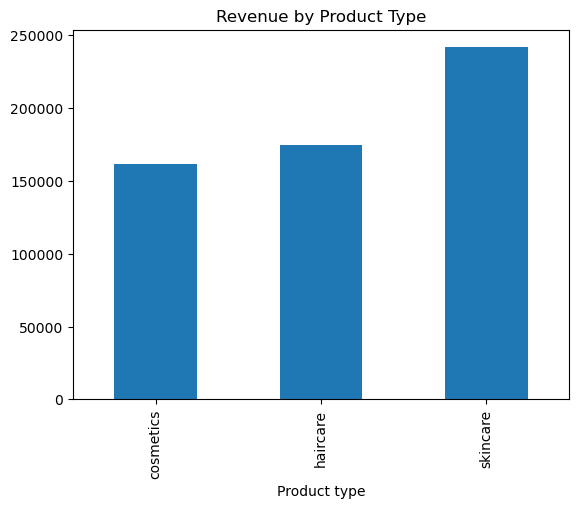

In [15]:
import matplotlib.pyplot as plt

df.groupby(
    'Product type'
)['Revenue generated'].sum().plot(
    kind='bar'
)

plt.title("Revenue by Product Type")
plt.show()

In [16]:
df['Stock levels'].mean()

np.float64(47.77)

In [17]:
df.sort_values(
    'Stock levels'
).head(10)

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
68,haircare,SKU68,37.931812,29,163,3550.218433,Non-binary,0,8,58,...,Bangalore,2,375,18,97.113582,Fail,1.983468,Rail,Route A,299.706303
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
34,skincare,SKU34,37.467592,96,602,9061.710896,Unknown,1,26,21,...,Chennai,4,452,10,10.754273,Pass,0.646605,Road,Route B,510.358000
16,skincare,SKU16,7.547172,74,280,6453.797968,Female,2,5,78,...,Bangalore,3,399,21,77.106342,Pass,1.012563,Air,Route A,865.525780
24,haircare,SKU24,4.156308,32,209,9049.077861,Male,4,26,2,...,Bangalore,28,447,3,40.382360,Pending,3.691310,Air,Route A,758.724773
47,skincare,SKU47,95.712136,93,910,7089.474250,Male,4,15,51,...,Kolkata,10,964,20,19.712993,Pending,0.380574,Rail,Route A,581.602355
33,cosmetics,SKU33,64.795435,63,616,5149.998350,Non-binary,4,17,95,...,Chennai,1,251,23,23.853428,Fail,3.541046,Sea,Route A,371.255296
8,cosmetics,SKU8,68.717597,78,150,7517.363211,Female,5,10,15,...,Mumbai,13,769,8,11.423027,Pending,2.709863,Sea,Route B,505.557134
78,haircare,SKU78,6.306883,50,946,1292.458418,Unknown,5,4,51,...,Mumbai,25,858,21,71.126515,Pending,4.096881,Sea,Route C,323.592203
57,haircare,SKU57,49.263205,65,227,1605.866900,Unknown,5,18,51,...,Delhi,21,588,25,67.779623,Pending,2.511175,Rail,Route A,482.191239


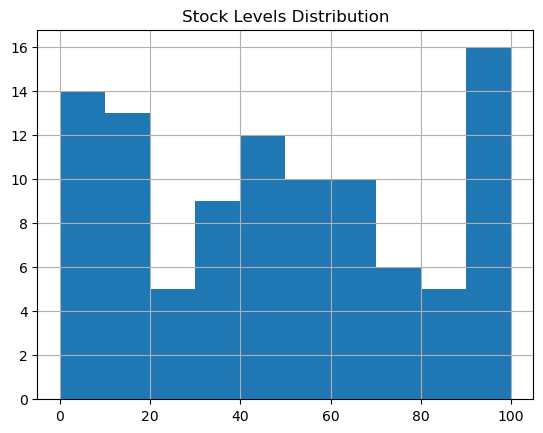

In [18]:
df['Stock levels'].hist()
plt.title("Stock Levels Distribution")
plt.show()

In [19]:
df.groupby(
    'Supplier name'
)['Defect rates'].mean().sort_values(
    ascending=False
)

Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64

In [20]:
df.groupby(
    'Shipping carriers'
)['Shipping costs'].mean().sort_values(
    ascending=False
)

Shipping carriers
Carrier C    5.599292
Carrier A    5.554923
Carrier B    5.509247
Name: Shipping costs, dtype: float64

In [21]:
df.groupby(
    'Transportation modes'
)['Costs'].mean()

Transportation modes
Air     561.712596
Rail    541.747556
Road    553.385988
Sea     417.819148
Name: Costs, dtype: float64

In [22]:
df['Inspection results'].value_counts()

Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64

In [23]:
df.groupby(
    'Product type'
)['Defect rates'].mean()

Product type
cosmetics    1.919287
haircare     2.483150
skincare     2.334681
Name: Defect rates, dtype: float64

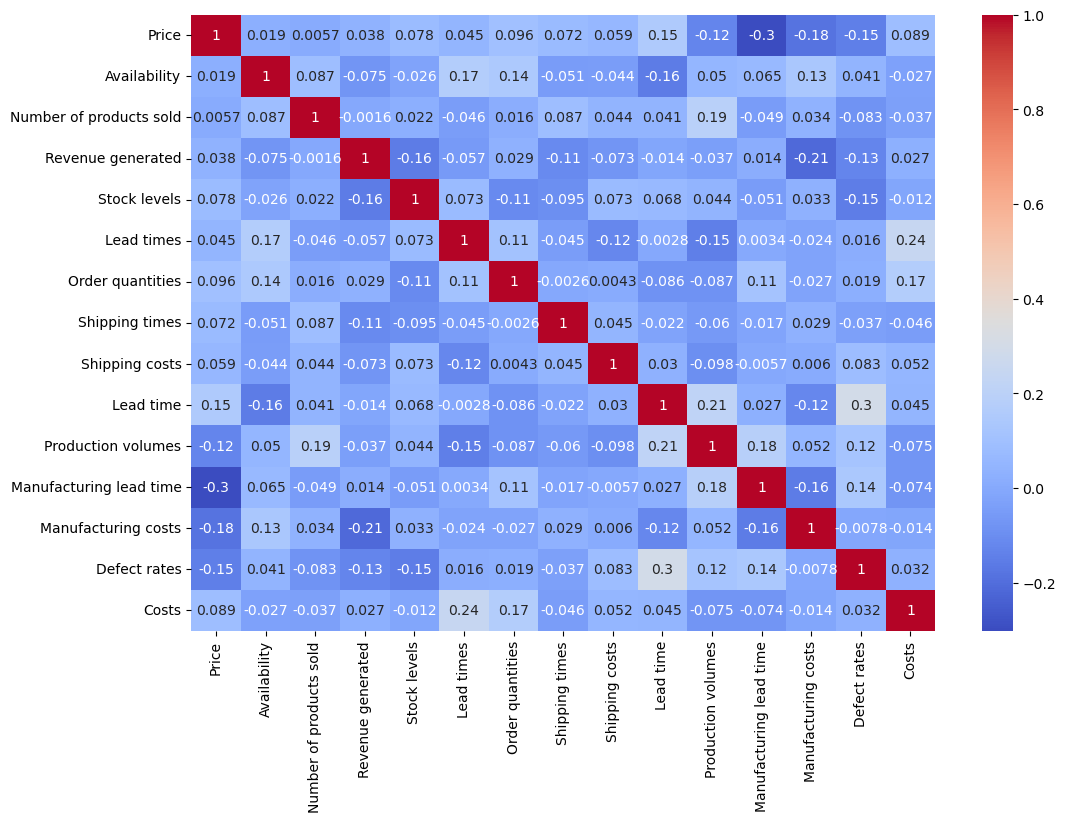

In [24]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [25]:
df['Revenue_per_Order'] = df['Revenue generated'] / df['Order quantities']

df['Cost_per_Product'] = df['Costs'] / df['Number of products sold']

In [26]:
corr = df.corr(numeric_only=True)

corr['Revenue generated'].sort_values(ascending=False)

Revenue generated          1.000000
Revenue_per_Order          0.163626
Cost_per_Product           0.105442
Price                      0.038424
Order quantities           0.029422
Costs                      0.027252
Manufacturing lead time    0.014073
Number of products sold   -0.001641
Lead time                 -0.014178
Production volumes        -0.037441
Lead times                -0.057296
Shipping costs            -0.072892
Availability              -0.075170
Shipping times            -0.109211
Defect rates              -0.125335
Stock levels              -0.158480
Manufacturing costs       -0.214025
Name: Revenue generated, dtype: float64

In [27]:
df_model = df.copy()

# Convert all categorical columns into numeric columns
df_model = pd.get_dummies(df_model, drop_first=True)

print(df_model.shape)

(100, 138)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop('Revenue generated', axis=1)
y = df_model['Revenue generated']

print(X.select_dtypes(include='object').columns.tolist())

[]


In [31]:
X.select_dtypes(include='object').columns.tolist()

[]

In [32]:
for col in X.columns:
    if X[col].dtype == 'object':
        print(col)

In [33]:
print(df_model.select_dtypes(include='object').columns.tolist())
print(X.select_dtypes(include='object').columns.tolist())

[]
[]


In [34]:
df_model = df.copy()

for col in df_model.select_dtypes(include='object').columns:
    print("Encoding:", col)

Encoding: Product type
Encoding: SKU
Encoding: Customer demographics
Encoding: Shipping carriers
Encoding: Supplier name
Encoding: Location
Encoding: Inspection results
Encoding: Transportation modes
Encoding: Routes


In [35]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

print(df_model.dtypes)

Product type                 int64
SKU                          int64
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics        int64
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers            int64
Shipping costs             float64
Supplier name                int64
Location                     int64
Lead time                    int64
Production volumes           int64
Manufacturing lead time      int64
Manufacturing costs        float64
Inspection results           int64
Defect rates               float64
Transportation modes         int64
Routes                       int64
Costs                      float64
Revenue_per_Order          float64
Cost_per_Product           float64
dtype: object


In [45]:
X = df_model.drop('Revenue generated', axis=1)
y = df_model['Revenue generated']

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df_model.drop('Revenue generated', axis=1)
y = df_model['Revenue generated']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = rf.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.6234429206884695
MAE: 1351.6283379801382
RMSE: 1739.5572763179837


In [48]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
23     Revenue_per_Order    0.619842
8       Order quantities    0.095060
17   Manufacturing costs    0.032105
24      Cost_per_Product    0.029726
6           Stock levels    0.027812
9         Shipping times    0.018738
15    Production volumes    0.017967
20  Transportation modes    0.016648
11        Shipping costs    0.016390
19          Defect rates    0.014171


In [47]:
print(len(X.columns))
print(len(rf.feature_importances_))

25
25


In [41]:
X = df_model.drop('Revenue generated', axis=1)
y = df_model['Revenue generated']

In [46]:
print(X.shape)

(100, 25)


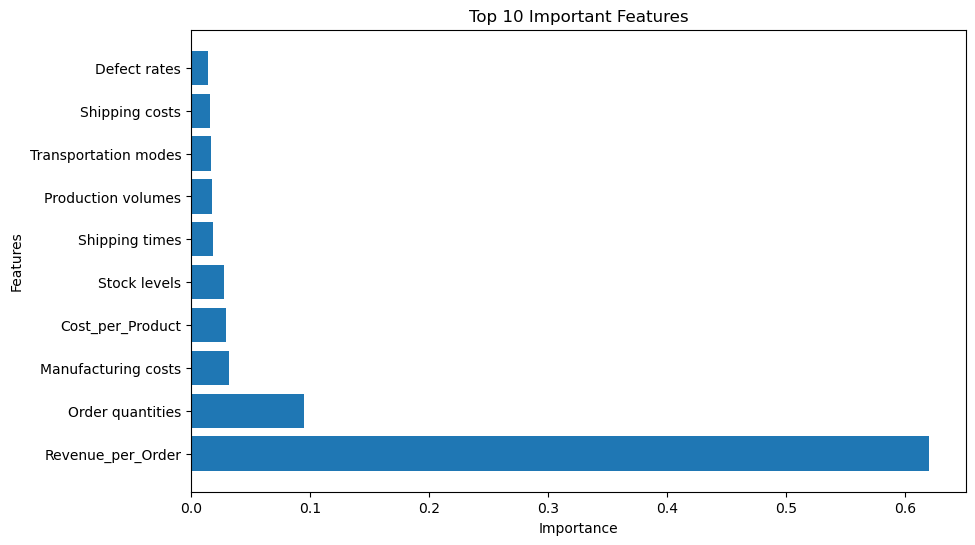

In [49]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()